<a href="https://colab.research.google.com/github/Ann-tech2025/Robotics-Final-Year-Project/blob/main/Facial_Emotion_detection_model_using_RAF_DB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Four Models trained and validated


In [ ]:
!unzip -q archive\ \(3\).zip -d ./my_data

replace ./my_data/test/angry/aug_101186.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!pip uninstall -y deepface
!pip install deepface==0.0.75
!pip install tensorflow opencv-python



Found existing installation: deepface 0.0.75
Uninstalling deepface-0.0.75:
  Successfully uninstalled deepface-0.0.75
  Using cached deepface-0.0.75-py3-none-any.whl.metadata (19 kB)
Using cached deepface-0.0.75-py3-none-any.whl (65 kB)


DeepFace Model

In [ ]:

# Fine-tune DeepFace VGG-Face on RAF-DB

# Step 1: Install DeepFace 0.0.75
!pip uninstall -y deepface
!pip install deepface==0.0.75
!pip install tensorflow opencv-python
# Step 3: Imports
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from deepface.basemodels import VGGFace
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Parameters

img_size = 224
batch_size = 32
epochs = 10
classes = ['angry','disgust','fear','happy','neutral','sad','surprise']

base_path = '/content/RAF-DB/'
train_path = os.path.join(base_path, 'train')
val_path   = os.path.join(base_path, 'val')
test_path  = os.path.join(base_path, 'test')

# Image generators

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    classes=classes
)
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    classes=classes
)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=1,
    shuffle=False,
    class_mode='categorical',
    classes=classes
)

os.makedirs('/root/.deepface/weights', exist_ok=True)
# Load pretrained VGG-Face
print("Loading pretrained VGG-Face model...")
base_model = VGGFace.loadModel()

x = base_model.layers[-2].output
x = GlobalAveragePooling2D()(x)
output = Dense(7, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

# Freeze all but last 5 layers
for layer in base_model.layers[:-5]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Train / fine-tune using generators

print("Training model...")
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)


# Evaluate on test set
pred_probs = model.predict(test_generator, steps=len(test_generator))
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)
print("Confusion Matrix:\n", cm)
print(classification_report(true_classes, pred_classes, target_names=classes, digits=4))

# Save trained model

model_save_path = '/content/RAF-DB-VGGFace-finetuned.h5'
model.save(model_save_path)
print(f"Trained model saved to {model_save_path}")

from google.colab import files
files.download(model_save_path)

Found existing installation: deepface 0.0.75
Uninstalling deepface-0.0.75:
  Successfully uninstalled deepface-0.0.75


 11%|█         | 62.9M/580M [00:19<00:23, 22.4MB/s]

  Using cached deepface-0.0.75-py3-none-any.whl.metadata (19 kB)
Using cached deepface-0.0.75-py3-none-any.whl (65 kB)


Found 30023 images belonging to 7 classes.
Found 7504 images belonging to 7 classes.
Found 4165 images belonging to 7 classes.
Loading pretrained VGG-Face model...
vgg_face_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5

  0%|          | 0.00/580M [00:00<?, ?B/s]
  2%|▏         | 11.0M/580M [00:00<00:13, 41.5MB/s]
  4%|▎         | 21.5M/580M [00:00<00:13, 40.1MB/s]
  4%|▍         | 25.7M/580M [00:00<00:16, 34.0MB/s]
  6%|▌         | 32.0M/580M [00:00<00:18, 29.8MB/s]
  7%|▋         | 42.5M/580M [00:01<00:16, 33.5MB/s]
  9%|▉         | 53.0M/580M [00:01<00:14, 35.3MB/s]
 11%|█         | 63.4M/580M [00:01<00:14, 34.8MB/s]
 13%|█▎        | 73.9M/580M [00:02<00:13, 36.3MB/s]
 15%|█▍        | 84.4M/580M [00:02<00:13, 36.5MB/s]
 16%|█▋        | 94.9M/580M [00:03<00:19, 24.6MB/s]
 18%|█▊        | 105M/580M [00:03<00:17, 27.1MB/s] 
 20%|█▉        | 116M/580M [00:03<00:15, 29.1MB/s]
 22%|██▏       | 126M/580M [00:03<00:14, 31.0MB/s]
 24%|██▎       | 137M/580M [00:04<00:13, 33.1MB/s]
 25%|██▌       | 147M/580M [00:04<00:12, 34.8MB/s]
 27%|██▋       | 158M/58

...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 287s 286ms/step - accuracy: 0.5110 - loss: 1.3221 - val_accuracy: 0.7224 - val_loss: 0.7902
Epoch 2/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 253s 270ms/step - accuracy: 0.7009 - loss: 0.8343 - val_accuracy: 0.8041 - val_loss: 0.5907
Epoch 3/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 285s 304ms/step - accuracy: 0.7646 - loss: 0.6601 - val_accuracy: 0.8417 - val_loss: 0.4788
Epoch 4/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 254s 271ms/step - accuracy: 0.8089 - loss: 0.5306 - val_accuracy: 0.8718 - val_loss: 0.4009
Epoch 5/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 254s 270ms/step - accuracy: 0.8361 - loss: 0.4602 - val_accuracy: 0.8891 - val_loss: 0.3413
Epoch 6/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 255s 271ms/step - accuracy: 0.8619 - loss: 0.3969 - val_accuracy: 0.8903 - val_loss: 0.3210
Epoch 7/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 254s 271ms/step - accuracy: 0.8798 - loss: 0.3503 - val_accuracy: 0.9115 - val_loss: 0.2749
Epoch 8/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 254s 271ms/step - accuracy: 0.8863 -

Confusion Matrix:
 [[585   3   0   0   4   2   1]
 [  3 577   0   6   6   2   1]
 [  0   0 592   0   1   1   1]
 [ 12  15   2 489  40  23  14]
 [  4  18   0  10 523  29  11]
 [  1   6   1   8  45 526   8]
 [  1   8   1   2  22   2 559]]
              precision    recall  f1-score   support

       angry     0.9653    0.9832    0.9742       595
     disgust     0.9203    0.9697    0.9444       595
        fear     0.9933    0.9950    0.9941       595
       happy     0.9495    0.8218    0.8811       595
     neutral     0.8159    0.8790    0.8463       595
         sad     0.8991    0.8840    0.8915       595
    surprise     0.9395    0.9395    0.9395       595

    accuracy                         0.9246      4165
   macro avg     0.9261    0.9246    0.9244      4165
weighted avg     0.9261    0.9246    0.9244      4165

Trained model saved to /content/RAF-DB-VGGFace-finetuned.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

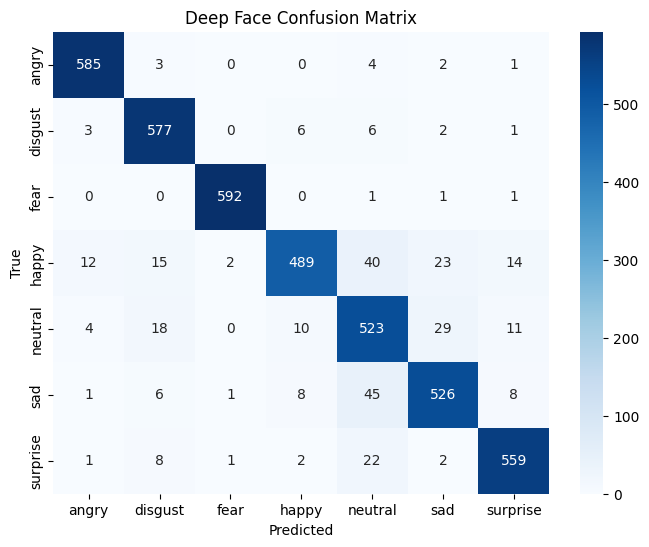

In [ ]:
# continue DeepFace VGG-Face on RAF-DB
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

cm = confusion_matrix(true_classes, pred_classes)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Deep Face Confusion Matrix')
plt.show()

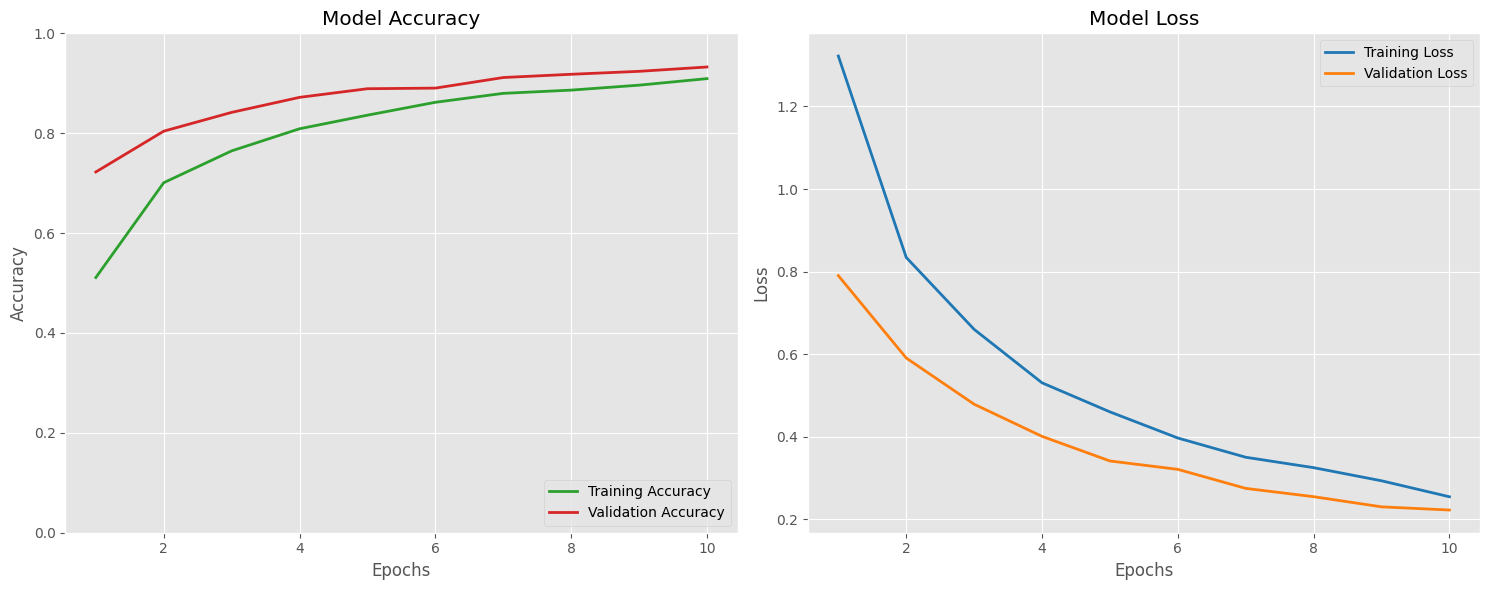

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

train_acc = [0.5110, 0.7009, 0.7646, 0.8089, 0.8361, 0.8619, 0.8798, 0.8863, 0.8962, 0.9093]
val_acc   = [0.7224, 0.8041, 0.8417, 0.8718, 0.8891, 0.8903, 0.9115, 0.9180, 0.9239, 0.9326]
train_loss = [1.3221, 0.8343, 0.6601, 0.5306, 0.4602, 0.3969, 0.3503, 0.3251, 0.2933, 0.2546]
val_loss   = [0.7902, 0.5907, 0.4788, 0.4009, 0.3413, 0.3210, 0.2749, 0.2548, 0.2302, 0.2225]

# Plotting
plt.style.use('ggplot')
plt.figure(figsize=(15, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Training Accuracy', color='#2ca02c', lw=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', color='#d62728', lw=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Training Loss', color='#1f77b4', lw=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='#ff7f0e', lw=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('accuracy_loss_plot.png', dpi=300)
plt.show()

CNN Model(Baseline)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# 1. Path Setup (Update if your unzip folder name is different)
base_dir = '/content/my_data'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

# 2. Data Generators (RGB)
# Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation/test, only rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=(48, 48), batch_size=128, # Increased batch size for GPU
    color_mode='rgb', class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir, target_size=(48, 48), batch_size=128,
    color_mode='rgb', class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir, target_size=(48, 48), batch_size=128,
    color_mode='rgb', class_mode='categorical', shuffle=False
)

# 3. Model Architecture
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48, 48, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Flatten + Dense
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(train_data.class_indices), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), # Slightly higher LR to start
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Smart Callbacks for Speed
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

# 5. Training
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100, # Max epochs, but EarlyStopping will likely cut it short
    callbacks=[early_stop, reduce_lr]
)

# 6. Save Model
model.save("emotion_detector_colab_rgb.h5")
print("✅ Model saved!")

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get predictions for the test data
# We use test_data because it has 'shuffle=False'
Y_pred = model.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1) # Convert probabilities to class index
y_true = test_data.classes        # The actual labels

# 2. Print the Classification Report
# This shows Precision, Recall, and F1-Score for each emotion
target_names = list(test_data.class_indices.keys())
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Emotion Detection Confusion Matrix')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

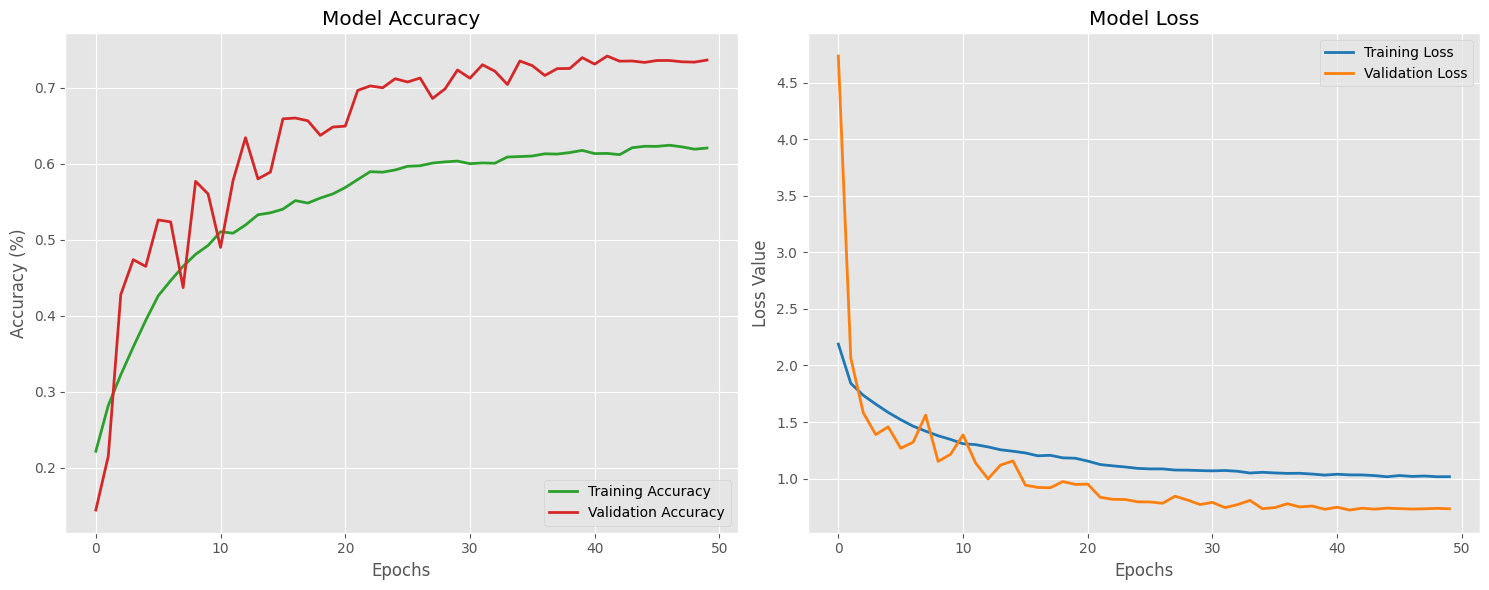

In [ ]:
# Set the style
plt.style.use('ggplot')

# Create a figure with two subplots (1 row, 2 columns)
plt.figure(figsize=(15, 6))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', lw=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True)

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
files.download('emotion_detector_colab_rgb.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Improved MobileNetV2 Model

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Path Setup
base_dir = '/content/my_data'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')

# Data Generators (with strong augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,        # smaller rotation for faces
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],   # simulate lighting
    channel_shift_range=20.0,      # color shifts
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=(96, 96), batch_size=64,
    color_mode='rgb', class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir, target_size=(96, 96), batch_size=64,
    color_mode='rgb', class_mode='categorical'
)

# Build Transfer Learning Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False  # freeze base initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# Label smoothing added here
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Use label smoothing (0.1) in loss
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Phase 1: Train Top Layers
print("Starting Phase 1: Training top layers...")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)
# Phase 2: Fine-Tuning Base
print("\nStarting Phase 2: Fine-Tuning base model...")
base_model.trainable = True

# Very small learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

model.save("emotion_mobilenet_v2_improved.h5")
print("✅ Transfer Learning Model Saved!")

import numpy as np
from collections import deque

# Maintain a deque of last N predictions
N = 10  # frames to average
prediction_history = deque(maxlen=N)

def smooth_prediction(probabilities):
    """
    probabilities: numpy array of shape (7,) from model.predict
    Returns: smoothed emotion index
    """
    prediction_history.append(probabilities)
    avg_prob = np.mean(prediction_history, axis=0)
    return np.argmax(avg_prob)

# Usage in live webcam:
# probs = model.predict(frame)
# smoothed_idx = smooth_prediction(probs)
# emotion_label = class_indices[smoothed_idx]


Found 30023 images belonging to 7 classes.
Found 7504 images belonging to 7 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Phase 1: Training top layers...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
470/470 ━━━━━━━━━━━━━━━━━━━━ 151s 281ms/step - accuracy: 0.3237 - loss: 2.1055 - val_accuracy: 0.4494 - val_loss: 1.5597
Epoch 2/25
470/470 ━━━━━━━━━━━━━━━━━━━━ 107s 227ms/step - accuracy: 0.4356 - loss: 1.5957 - val_accuracy: 0.4418 - val_loss: 1.6175
Epoch 3/25
470/470 ━━━━━━━━━━━━━━━━━━━━ 108s 229ms/step - accuracy: 0.4580 - loss: 1.5448 - val_accuracy: 0.4857 - val_loss: 1.5092
Epoch 4/25
470/470 ━━━━━━━━━━━━━━━━━━━━ 103s 220ms/step - accuracy: 0.4791 - loss: 1.5099 - val_accuracy: 0.5060 - val_loss: 1.4621
Epoch 5/25
470/470 ━━━━━━━━━━━━━━━━━━━━ 102s 217ms/step - accuracy: 0.4840 - loss: 1.4965 - val_accuracy: 0.4935 - val_loss: 1.4965
Epoch 6/25
470/470 ━━━━━━━━━━━━━━━━━━━━ 145s 224ms/step - accuracy: 0.4863 - loss: 1.4929 - val_accuracy: 0.4813 - val_loss: 1.4919
Epoch 7/25
470/470 ━━━━━━━━━━━━━━━━━━━━ 106s 226ms/step - accuracy: 0.4969 - loss: 1.4831 - val_accuracy: 0.4993 - val_loss: 1.4726
Epoch 8/25
470/470 ━━━━━━━━━━━━━━━━━━━━ 106s 226ms/step - accuracy: 0.5001 -

✅ Transfer Learning Model Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8356 - loss: 0.8344
Validation Loss: 0.8357
Validation Accuracy: 83.46%
118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step


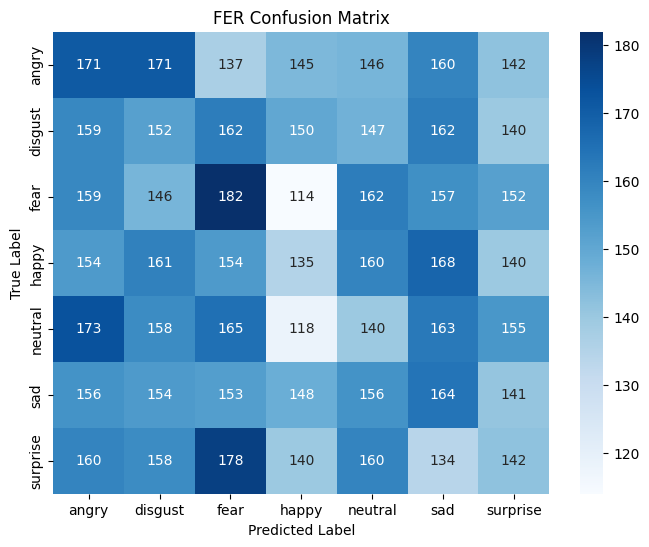

              precision    recall  f1-score   support

       angry       0.15      0.16      0.16      1072
     disgust       0.14      0.14      0.14      1072
        fear       0.16      0.17      0.17      1072
       happy       0.14      0.13      0.13      1072
     neutral       0.13      0.13      0.13      1072
         sad       0.15      0.15      0.15      1072
    surprise       0.14      0.13      0.14      1072

    accuracy                           0.14      7504
   macro avg       0.14      0.14      0.14      7504
weighted avg       0.14      0.14      0.14      7504



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model

from google.colab import files
files.download('emotion_mobilenet_v2_improved.h5')

# Prepare test/validation data

# Evaluate model on test data

loss, acc = model.evaluate(val_data)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc*100:.2f}%")


# predict classes
val_data.reset()  # Ensure generator is at start
y_pred_prob = model.predict(val_data)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_data.classes


# confusion Matrix

class_names = list(val_data.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('FER Confusion Matrix')
plt.show()


# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


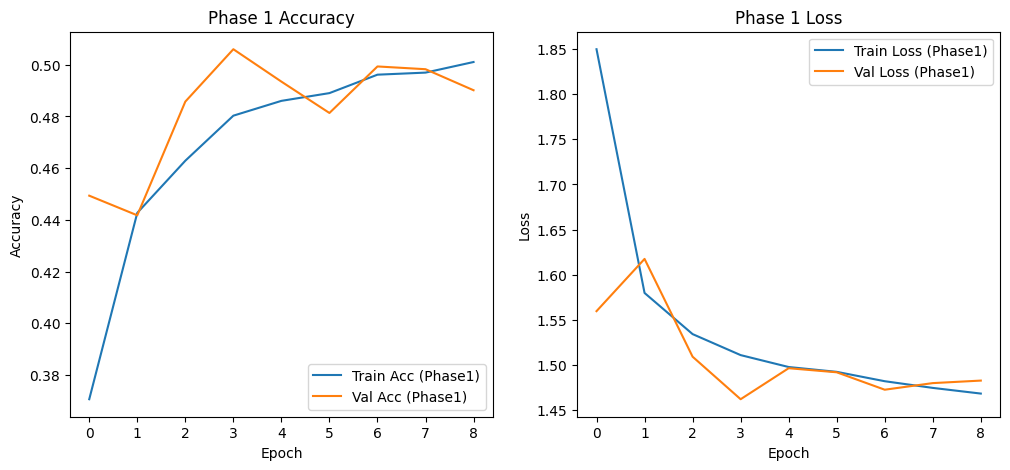

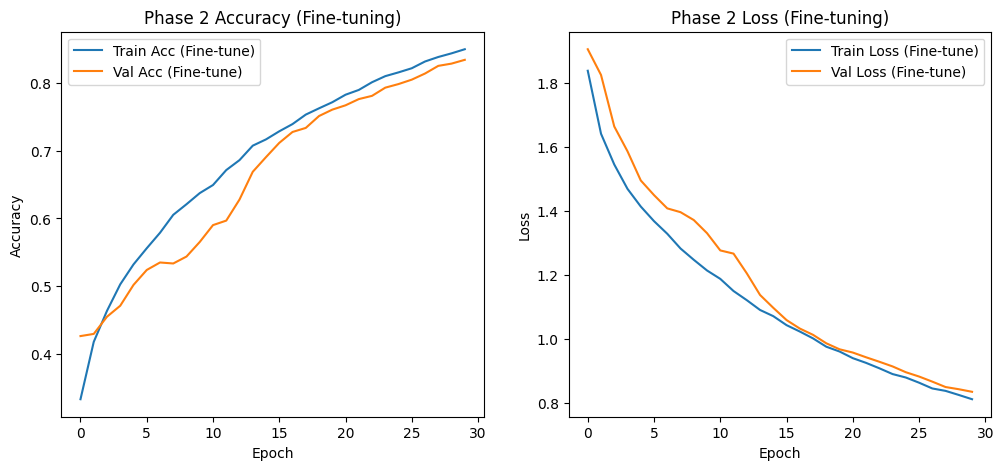

In [ ]:
import matplotlib.pyplot as plt

# 1️⃣ Phase 1: Top layers

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc (Phase1)')
plt.plot(history.history['val_accuracy'], label='Val Acc (Phase1)')
plt.title('Phase 1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss (Phase1)')
plt.plot(history.history['val_loss'], label='Val Loss (Phase1)')
plt.title('Phase 1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 2️⃣ Phase 2: Fine-tuning
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_fine.history['accuracy'], label='Train Acc (Fine-tune)')
plt.plot(history_fine.history['val_accuracy'], label='Val Acc (Fine-tune)')
plt.title('Phase 2 Accuracy (Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_fine.history['loss'], label='Train Loss (Fine-tune)')
plt.plot(history_fine.history['val_loss'], label='Val Loss (Fine-tune)')
plt.title('Phase 2 Loss (Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


MobileNetV2 Model

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Path Setup
base_dir = '/content/my_data'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')

# 2. Data Generators (Updated to 96x96)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=(96, 96), batch_size=64, # 96x96 is better for MobileNet
    color_mode='rgb', class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir, target_size=(96, 96), batch_size=64,
    color_mode='rgb', class_mode='categorical'
)

# 3. Build Transfer Learning Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False # Freeze the pre-trained weights initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Phase 1: Training the "Head"
print("Starting Phase 1: Training top layers...")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# 5. Phase 2: Fine-Tuning (Unfreeze the base)
print("\nStarting Phase 2: Fine-Tuning...")
base_model.trainable = True

# We use a VERY small learning rate so we don't "break" the pre-trained weights
model.compile(optimizer=Adam(learning_rate=0.00001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

model.save("emotion_mobilenet_v2.h5")
print("✅ Transfer Learning Model Saved!")

Found 30023 images belonging to 7 classes.
Found 7504 images belonging to 7 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Phase 1: Training top layers...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
470/470 ━━━━━━━━━━━━━━━━━━━━ 126s 233ms/step - accuracy: 0.2995 - loss: 2.1008 - val_accuracy: 0.3969 - val_loss: 1.5922
Epoch 2/20
470/470 ━━━━━━━━━━━━━━━━━━━━ 85s 181ms/step - accuracy: 0.4007 - loss: 1.5843 - val_accuracy: 0.4215 - val_loss: 1.5198
Epoch 3/20
470/470 ━━━━━━━━━━━━━━━━━━━━ 86s 182ms/step - accuracy: 0.4165 - loss: 1.5374 - val_accuracy: 0.4186 - val_loss: 1.5225
Epoch 4/20
470/470 ━━━━━━━━━━━━━━━━━━━━ 85s 181ms/step - accuracy: 0.4259 - loss: 1.5257 - val_accuracy: 0.4291 - val_loss: 1.5157
Epoch 5/20
470/470 ━━━━━━━━━━━━━━━━━━━━ 85s 180ms/step - accuracy: 0.4330 - loss: 1.5010 - val_accuracy: 0.4540 - val_loss: 1.4498
Epoch 6/20
470/470 ━━━━━━━━━━━━━━━━━━━━ 86s 184ms/step - accuracy: 0.4349 - loss: 1.4888 - val_accuracy: 0.4312 - val_loss: 1.5033
Epoch 7/20
470/470 ━━━━━━━━━━━━━━━━━━━━ 85s 180ms/step - accuracy: 0.4366 - loss: 1.4851 - val_accuracy: 0.4520 - val_loss: 1.4571
Epoch 8/20
470/470 ━━━━━━━━━━━━━━━━━━━━ 85s 181ms/step - accuracy: 0.4377 - loss: 

✅ Transfer Learning Model Saved!


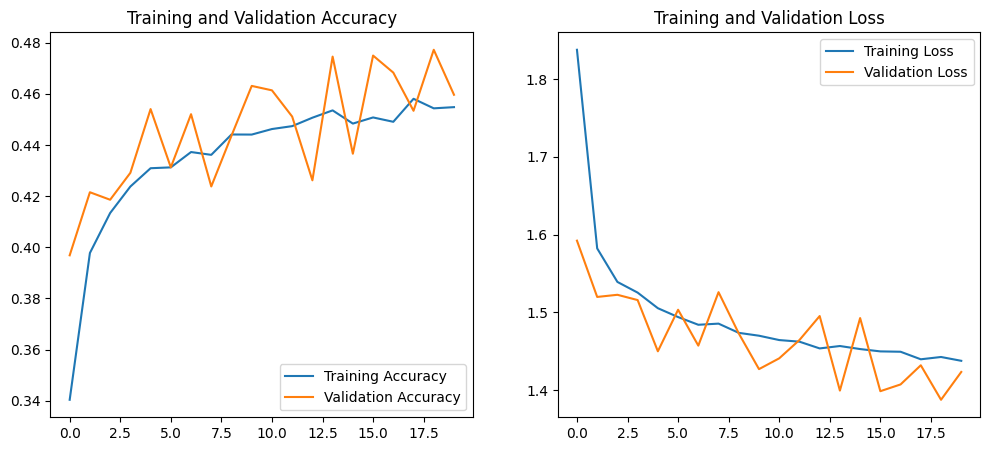

In [ ]:
# Assuming your history variable was named 'history'
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()

In [ ]:

test_datagen = ImageDataGenerator(rescale=1./255)

final_test_generator = test_datagen.flow_from_directory(
    'my_data/test',
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 2. Run the final assessment
print("Running the Final Exam on the Test Folder...")
Y_pred = model.predict(final_test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = final_test_generator.classes

# 3. Get the report
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=list(final_test_generator.class_indices.keys())))

Found 4165 images belonging to 7 classes.
Running the Final Exam on the Test Folder...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


131/131 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step
              precision    recall  f1-score   support

       angry       0.79      0.88      0.83       595
     disgust       0.75      0.70      0.72       595
        fear       0.88      0.90      0.89       595
       happy       0.93      0.73      0.82       595
     neutral       0.60      0.63      0.61       595
         sad       0.68      0.66      0.67       595
    surprise       0.76      0.85      0.80       595

    accuracy                           0.76      4165
   macro avg       0.77      0.76      0.76      4165
weighted avg       0.77      0.76      0.76      4165



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Setup the Test Generator pointing to your 'test' folder
test_datagen = ImageDataGenerator(rescale=1./255)
_
test_generator = test_datagen.flow_from_directory(
    'my_data/test',   # Replace with your actual path
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    shuffle=False     # Crucial for matching labels!
)

# 2. Evaluate
results = model.evaluate(test_generator)
print(f"\nFinal Test Loss: {results[0]:.4f}")
print(f"Final Test Accuracy: {results[1]:.4f}")

Found 4165 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.8046 - loss: 0.5604

Final Test Loss: 0.6571
Final Test Accuracy: 0.7642


131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step

--- Final Classification Report ---
              precision    recall  f1-score   support

       angry       0.79      0.88      0.83       595
     disgust       0.75      0.70      0.72       595
        fear       0.88      0.90      0.89       595
       happy       0.93      0.73      0.82       595
     neutral       0.60      0.63      0.61       595
         sad       0.68      0.66      0.67       595
    surprise       0.76      0.85      0.80       595

    accuracy                           0.76      4165
   macro avg       0.77      0.76      0.76      4165
weighted avg       0.77      0.76      0.76      4165



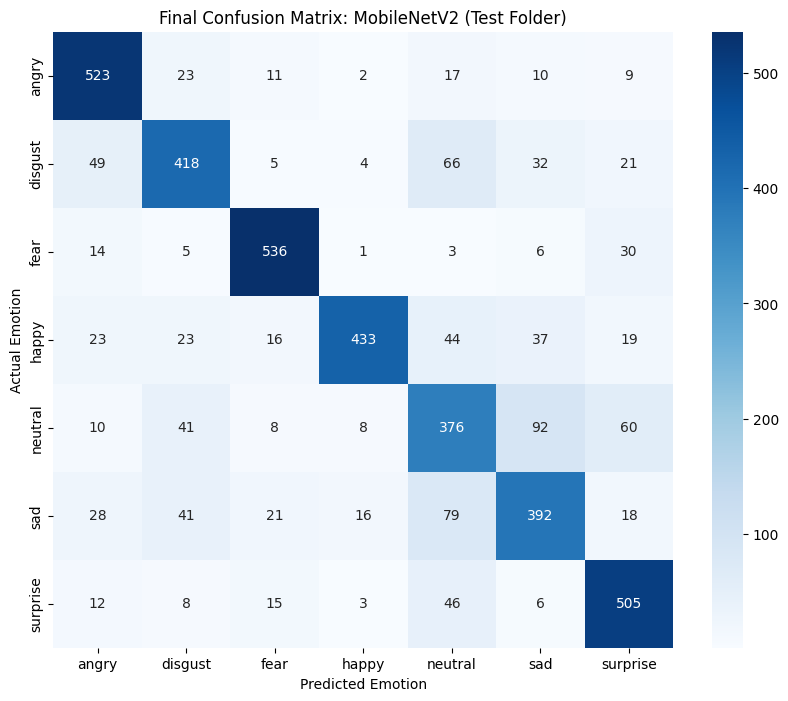

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get predictions from the test generator
test_generator.reset() # Ensure we start from the beginning
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1) # Predicted classes
y_true = test_generator.classes    # Actual classes
target_names = list(test_generator.class_indices.keys())

# 2. Print Classification Report (Precision, Recall, F1)
print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Final Confusion Matrix: MobileNetV2 (Test Folder)')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()